# Project Demo by Jack Mulvihill

## Research Question
**Given** the OpenAlex tables “Works” and “Works Authorships” provide information about
citation counts, authors, and the institution that published these works between 2020 and 2025.

**Then** we aim to identify which institutions and combinations of institutions are most frequently
associated with highly cited research during this period.

**How** we will approach this is by each highly cited paper we will look at the institutions
represented by its authors and analyze which institutions frequently appear together in impactful
research. Using frequent pattern mining we will identify recurring patterns and determine which
combinations are most associated with highly cited works.


## Institutions Publishing Highly Cited Works and their Co-Authorship Patterns

## Imported Libraries

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow.parquet as pypq
import textwrap 

# For sampling
import random

# For Apriori (Frequent Pattern Mining)
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# For counting and filtering frequent item pairs
from collections import Counter

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)

# ---------------------------------------------------------
# 📂 GLOBAL PATHS - DO NOT CHANGE THESE
# ---------------------------------------------------------
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"
CSV_PATH = BASE_PATH / "csv-files" / "may-2025"

print(f"✅ Data Directories Set:\n  - Parquet: {PARQUET_PATH}\n  - CSV: {CSV_PATH}")

# Focusing on works published within the past five years
MIN_YEAR = 2020
MAX_YEAR = 2025

# A work with 100 or more citations is considered "highly cited"
MIN_CITS = 100

✅ Data Directories Set:
  - Parquet: /data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025
  - CSV: /data/shared/OpenAlex/processed-snapshots/csv-files/may-2025


## Peek Parquet (Inspects File Schemas)

In [2]:
def peek_parquet(path):
    """
    peeks at a parquet file (or a directory containing parquet files) without reading the whole thing and prints the following:
    * Path
    * schema
    * number of pieces (fragments)
    * number of rows 
    """
    path = Path(path)
    parq_file = pypq.ParquetDataset(path)
    piece_count = len(parq_file.fragments)
    schema = textwrap.indent(parq_file.schema.to_string(), ' '*4)
    row_count = sum(frag.count_rows() for frag in parq_file.fragments)
    
    st = [
        f'Name: {path.stem!r}',  
        f'Path: {str(path)!r}',
        f'Files: {piece_count:,}',
        f'Rows: {row_count:,}',
        f'Schema:\n{schema}',
        f'5 random rows:',
    ]
    print('\n'.join(st))
    sample_df = parq_file.fragments[0].head(5).to_pandas()  # read 5 rows from the first fragment
    display(sample_df)

    return

## Primary Tables: Works and Works Authorships

In [3]:
peek_parquet(PARQUET_PATH / 'works')

Name: 'works'
Path: '/data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025/works'
Files: 879
Rows: 267,515,390
Schema:
    work_id: int64
    doi: string
    title: string
    publication_year: int16
    publication_date: timestamp[ms]
    type: dictionary<values=string, indices=int32, ordered=0>
    type_crossref: dictionary<values=string, indices=int32, ordered=0>
    cited_by_count: uint32
    num_authors: uint16
    num_locations: uint16
    num_references: uint16
    language: dictionary<values=string, indices=int32, ordered=0>
    has_complete_institution_info: bool
    has_grant_info: bool
    has_keywords: bool
    is_retracted: bool
    is_paratext: bool
    created_date: timestamp[ms]
    gz_path: dictionary<values=string, indices=int32, ordered=0>
    -- schema metadata --
    pandas: '{"index_columns": [], "column_indexes": [{"name": null, "field_n' + 2664
5 random rows:


,work_id,doi,title,publication_year,publication_date,type,type_crossref,cited_by_count,num_authors,num_locations,num_references,language,has_complete_institution_info,has_grant_info,has_keywords,is_retracted,is_paratext,created_date,gz_path
0,4298954679,<NA>,Anomalous cooling of the parallel velocity in seeded beams,2004,2004-06-16,article,posted-content,0,4,6,0,en,False,False,False,False,False,2022-10-02,2023-05-29_part_000
1,4367174134,10.41014/jmb.2301.01011,Comparative Genomic Analysis and BTEX Degradation Pathways of a Thermotolera...,2023,2023-04-10,article,journal-article,0,6,1,0,en,True,False,False,False,False,2023-04-28,2023-05-29_part_000


In [4]:
# Construct a dataframe from the original parquet files
works_df = (
  pd.read_parquet(
    PARQUET_PATH / 'works',

    # Include relevant columns to this analysis
    columns=['work_id', 'title', 'cited_by_count', 
             'num_references', 'has_complete_institution_info'],

    # Only include papers published within the last five years
    # Only include papers that have received 100 or more citations
    # Make sure it has complete information about publication
    filters=[
      [
        ('publication_year', '>=', MIN_YEAR), ('publication_year', '<=', MAX_YEAR),
        ('cited_by_count', '>=', MIN_CITS), ('has_complete_institution_info', '==', True), 
      ]
    ],
  )
)

This dataframe only contains works from the works table that are "highly cited," are within the desired period of analysis, and have complete information about their institution of origin.

In [5]:
display(works_df.head())

,work_id,title,cited_by_count,num_references,has_complete_institution_info
0,4223541591,A comprehensive review on the adsorption of heavy metals by zeolite imidazol...,184,157,True
1,4225729190,Monostotic Fibrous Dysplasia,115,0,True
2,2909533002,Similarity and Self-Esteem in Downward Comparison,175,0,True
3,4296018328,The economics of medication safety,137,138,True
4,4395654955,Institut Mediterrani d'Estudis Avançats (CSIC-UIB): IMEDEA-INSECTA,301,0,True


In [6]:
peek_parquet(PARQUET_PATH / 'works_authorships')

Name: 'works_authorships'
Path: '/data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025/works_authorships'
Files: 876
Rows: 955,891,469
Schema:
    work_id: int64
    author_position: dictionary<values=string, indices=int32, ordered=0>
    author_id: int64
    author_name: string
    raw_author_name: string
    institution_lineage_level: int8
    assigned_institution: bool
    institution_id: int64
    institution_name: dictionary<values=string, indices=int32, ordered=0>
    country_code: dictionary<values=string, indices=int32, ordered=0>
    raw_affiliation_string: string
    publication_year: int16
    is_corresponding: bool
    -- schema metadata --
    pandas: '{"index_columns": [], "column_indexes": [{"name": null, "field_n' + 1971
5 random rows:


,work_id,author_position,author_id,author_name,raw_author_name,institution_lineage_level,assigned_institution,institution_id,institution_name,country_code,raw_affiliation_string,publication_year,is_corresponding
0,4298954679,first,5058811708,Alain Miffre,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
1,4298954679,middle,5030850284,Marion Jacquey,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
2,4298954679,middle,5080689989,Gérard Trénec,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
3,4298954679,last,5025008933,J. Vigué,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
4,4367174134,first,5051167699,Chandran Sathesh-Prabu,<NA>,0,False,<NA>,NaN,NaN,"School of Energy and Chemical Engineering, Ulsan National Institute of Scien...",2023,False


In [7]:
# A set of the relevant work IDs (highly cited)
# Use a set to avoid storing duplicates
work_ids = set(works_df.work_id)

# Construct a dataframe from the original parquet files
works_authors_df = (
  pd.read_parquet(
    PARQUET_PATH / 'works_authorships',

    # Include relevant columns to this analysis
    columns=['work_id', 'author_id', 'author_name', 
             'institution_id', 'institution_name', 'publication_year'],
    
    # Make sure the works stored in this dataframe fit the initial filters
    # Only include works published in the last five years
    filters=[[
      ('work_id', 'in', work_ids),
      ('publication_year', '>=', MIN_YEAR), ('publication_year', '<=', MAX_YEAR)
    ]],
  )
)

This dataframe builds upon works_df by storing information about the authors, institution of origin, and publication year of the works filtered out in the previous step.

In [8]:
display(works_authors_df)

,work_id,author_id,author_name,institution_id,institution_name,publication_year
0,4223541591,5013500365,Zhenlin Mo,38706770,Guilin University of Technology,2022
1,4223541591,5046683824,Dezhi Tai,38706770,Guilin University of Technology,2022
2,4223541591,5100408669,Hua Zhang,38706770,Guilin University of Technology,2022
3,4223541591,5077721323,Asfandyar Shahab,38706770,Guilin University of Technology,2022
4,4225729190,5073357492,Joshua Brooks,117397414,Aurora Health Care,2021
...,...,...,...,...,...,...
2079792,4388865570,5101235563,Pengpeng Xie,75390827,Beijing University of Chemical Technology,2023
2079793,4388865570,5051035374,Linfeng Yu,75390827,Beijing University of Chemical Technology,2023
2079794,4388865570,5101814251,Liang Luo,75390827,Beijing University of Chemical Technology,2023
2079795,4388865570,5100382892,Xiaoming Sun,75390827,Beijing University of Chemical Technology,2023


# Which Institutions Receive the Most Citations Across Published Works?

In [9]:
# Create a temporary dataframe to merge the works and works_authors tables
temp_df = pd.merge(
    works_authors_df,
    works_df,

    # They both share work_id
    on='work_id',

    # Combines rows when there is a matching column
    how='inner'
)

# Drop duplicates from the newly merged dataframes, keep first occurrence
# Pay attention to work ID and institution ID combos for identifying duplicates
works_institutions_df = temp_df.drop_duplicates(keep='first', subset=['work_id', 'institution_id'])

Merge the desired information of both previously created dataframes into one for easier analysis.

In [10]:
display(works_institutions_df.head())

,work_id,author_id,author_name,institution_id,institution_name,publication_year,title,cited_by_count,num_references,has_complete_institution_info
0,4223541591,5013500365,Zhenlin Mo,38706770,Guilin University of Technology,2022,A comprehensive review on the adsorption of heavy metals by zeolite imidazol...,184,157,True
4,4225729190,5073357492,Joshua Brooks,117397414,Aurora Health Care,2021,Monostotic Fibrous Dysplasia,115,0,True
5,4225729190,5073357492,Joshua Brooks,4210119112,Aurora St. Luke's Medical Center,2021,Monostotic Fibrous Dysplasia,115,0,True
8,2909533002,5011300391,Thomas A. Wills,129975664,Albert Einstein College of Medicine,2024,Similarity and Self-Esteem in Downward Comparison,175,0,True
9,2909533002,5011300391,Thomas A. Wills,4210112371,Montefiore Health System,2024,Similarity and Self-Esteem in Downward Comparison,175,0,True


In [11]:
# Find the total number of citations among all works published by an institution
total_citations = (
    works_institutions_df

    # Group citation counts by institution ID in the event of duplicate names
    .groupby('institution_id')
    .agg(

        # Look at the first occurrence of the institution name
        institution=('institution_name', 'first'),

        # Sum up total citations for each institution across all of their published works
        total_citations=('cited_by_count', 'sum'),
    )
        
     # Sort by total citation count in descending order
    .sort_values(by='total_citations', ascending=False)
)

In [12]:
display(total_citations)

,institution,total_citations
institution_id,,
19820366,Chinese Academy of Sciences,1930477
124357947,University of London,1158397
136199984,Harvard University,1095164
1294671590,Centre National de la Recherche Scientifique,806896
99065089,Tsinghua University,680096
...,...,...
4210138201,3E (Belgium),100
4403928403,Pharmaceutical Sciences Research Center,100
4210129657,Delta Electronics (Taiwan),100


For each unique institution ID, sum up the total number of citations they received across all works published within the desired time range. Orders institutions by total citations received across all works in descending order.

[Text(0, 0, '1.93048e+06'),
 Text(0, 0, '1.1584e+06'),
 Text(0, 0, '1.09516e+06'),
 Text(0, 0, '806896'),
 Text(0, 0, '680096'),
 Text(0, 0, '641773'),
 Text(0, 0, '621175'),
 Text(0, 0, '614091'),
 Text(0, 0, '586533'),
 Text(0, 0, '586178')]

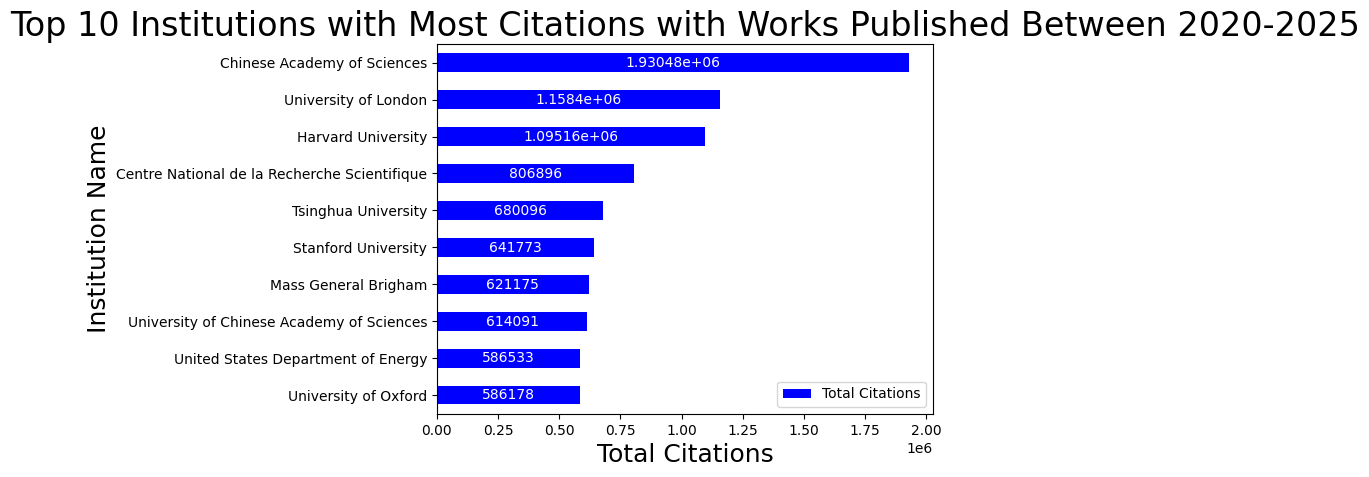

In [13]:
# Plot the top ten institutions with most citations across works published
# Dataframe is sorted, first 10 rows will have the most citations
ten_most_cited = total_citations.head(10).plot.barh(
    x='institution',
    y='total_citations',
    color='blue'
)

# Title and label the graph as approprite
ten_most_cited.set_title(label='Top 10 Institutions with Most Citations with Works Published Between 2020-2025', fontsize=24, color='black')
ten_most_cited.set_xlabel('Total Citations', fontsize=18, color='black')
ten_most_cited.set_ylabel('Institution Name', fontsize=18, color='black')
ten_most_cited.legend(['Total Citations'])

# Invert the y-axis to sort the bars in descending order
ten_most_cited.invert_yaxis()

# Annotate the bars
ten_most_cited.bar_label(ten_most_cited.containers[0], label_type='center', color='white')

Visualizes the total_citations table. These are the top ten institutions that have received the most citations across all works they published between the years 2020-2025.

# Co-Authorship Patterns Among Institutions

## Mapping Institution IDs

In [14]:
# Map an institution ID to its name 
institution_map = (
    works_institutions_df
    .groupby('institution_id')['institution_name']
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)

# Preview mapping entries
print(f"Institution map: {len(institution_map):,} entries")
print("\nSample entries:")
for iid, name in list(institution_map.items())[:5]:
    print(f"{iid} → {name}")

Institution map: 28,396 entries

Sample entries:
9507 → Sangji University
19722 → Ateneo de Manila University
41870 → Military Institute of Engineering
43886 → Sapientia Hungarian University of Transylvania
46017 → Kahramanmaraş Sütçü İmam University


## Building Transactions

In [15]:
# Group each work ID to a set of institution IDs
work_institutions = (
    works_institutions_df
    .groupby('work_id')['institution_id']
    .apply(set)
)

# Convert to a list of lists for mlxtend
transactions = [list(institutions) for institutions in work_institutions]

# Preview the first transaction
sample_work  = work_institutions.index[0]
sample_ids   = transactions[0]
sample_names = [institution_map.get(a, 'Unknown') for a in sample_ids]
print(f"\nSample transaction (work_id={sample_work}):")
print(f"institution_id(s) : {sample_ids}")
print(f"name(s)           : {sample_names}")


Sample transaction (work_id=2402700):
institution_id(s) : [np.int64(1290206253)]
name(s)           : ['Microsoft (United States)']


In [16]:
# Since this project explores all topics, much more data to load so use a sample to prevent kernel crashes
SAMPLE_SIZE = 10000

# Fix the seed so re-running this cell gives the same sample
random.seed(42)
if len(transactions) > SAMPLE_SIZE:
    transactions = random.sample(transactions, SAMPLE_SIZE)

## Constructing TransactionEncoder (for Apriori)

In [17]:
# Converts the transaction matrix into a one-hot encoded dataframe
# Required input format for Apriori to run
te = TransactionEncoder()

# Use fit_transform to learn the full item univerise, then encode each transaction
te_array = te.fit_transform(transactions)

# Construct a dataframe from the encoded matrix where columns represent institution IDs
te_df = pd.DataFrame(te_array, columns=te.columns_)

# Display the dimensions of the te matrix
print(f"Encoded matrix shape: {te_df.shape}")
print(f"{te_df.shape[0]:,} rows  (works / transactions)")
print(f"{te_df.shape[1]:,} cols  (unique institutions / items)")

# Display the sparsity of the matrix
sparsity = (~te_df).sum().sum() / te_df.size
print(f"\nSparsity: {sparsity:.2%} of values are False")

te_df.head()

Encoded matrix shape: (10000, 9387)
10,000 rows  (works / transactions)
9,387 cols  (unique institutions / items)

Sparsity: 99.95% of values are False


,9507,46017,52325,80043,215927,226432,241749,251738,280994,308837,...,4403928192,4403928244,4403928267,4403928284,4403928356,4403928377,4407990293,4407990318,4407990431,4410514767
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
# Detect names shared by more than one institution ID
name_counts = pd.Series(institution_map.values()).value_counts()
duplicate_iids = set(name_counts[name_counts > 1].index)

# Build display label to differentiate institutions that share the same name
# Will be plain if the name is unique, in the format "Name [id]" if shared
institution_display_map = {
    iid: (f"{name} [{iid}]" if name in duplicate_iids else name)
    for iid, name in institution_map.items()
}

# Label the transaction encoder dataframe using the display map
labeled_te_df = te_df.rename(columns=institution_display_map)

labeled_te_df.head()

,Sangji University,Kahramanmaraş Sütçü İmam University,Fundação Oswaldo Cruz,Institut Curie,University of Madras,Universiti Malaysia Kelantan,University of Cambridge,Edinburgh Napier University,King George's Medical University,Suzhou University of Science and Technology,...,Endocrinology and Metabolism Population Sciences Institute,"Istituto Nazionale di Fisica Nucleare, Gruppo Collegato di Udine",International Laboratory on Learning Systems,Institut für Mikrobiologie der Bundeswehr,Non-Communicable Diseases Research Center,Endocrine & Metabolism Research Institute,Université Marie et Louis Pasteur,Indiana University Columbus,Université Bourgogne Europe,Stichting Aeres Groep
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Apriori Search

In [19]:
# Testing five different min support thresholds: 
# institutions appearing in 0.25%, 0.3%, 0.35%, 0.4%, and 0.5% of papers respectively
min_supports = [0.0025, 0.003, 0.0035, 0.004, 0.005]
counts = []
for ms in min_supports:
    fi = apriori(labeled_te_df, min_support=ms, use_colnames=True, verbose=0)

    # Append the length of each set of frequent itemsets to the list counts
    counts.append(len(fi))

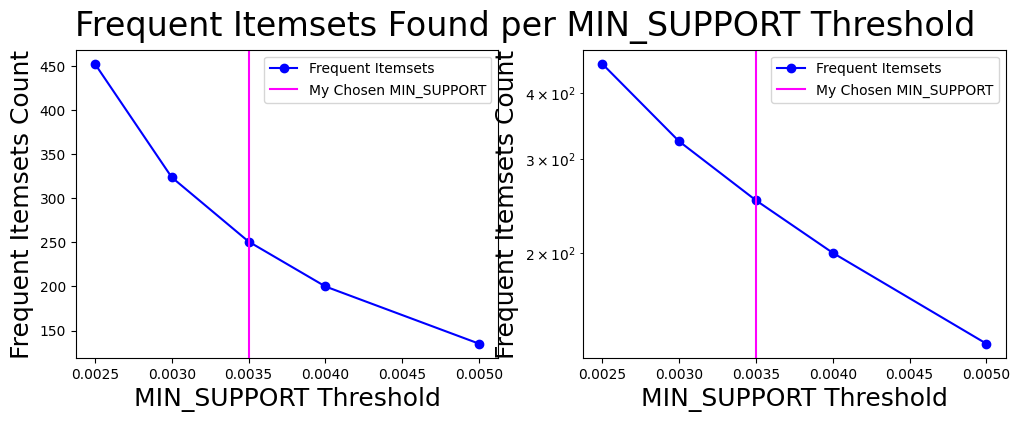

In [22]:
# Convert the array data obtained from the Apriori search to dataframes for plotting
min_supports_df = pd.DataFrame(min_supports, columns=["MIN_SUPPORT"])
counts_df = pd.DataFrame(counts, columns=["Frequent Itemsets"])

# Construct a temporary dataframe combining the information for the minimum support
# and frequent itemsets counts to plot
min_supports_to_itemsets = pd.concat([min_supports_df, counts_df], axis=1)

# Construct two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Set a single title for both plots
fig.suptitle('Frequent Itemsets Found per MIN_SUPPORT Threshold', fontsize=24, color='black')

# Plot the combined dataframe on the left panel
ax1 = min_supports_to_itemsets.plot(x='MIN_SUPPORT', y='Frequent Itemsets', ax=ax1, color='blue', marker='o')

# Label the axes as appropriate
ax1.set_xlabel('MIN_SUPPORT Threshold', fontsize=18, color='black')
ax1.set_ylabel('Frequent Itemsets Count', fontsize=18, color='black')

# Add a vertical line annotation on the left panel for my chosen MIN_SUPPORT threshold
ax1.axvline(x=0.0035, color='magenta')

# Add a legend to the left panel to annotate the graph line and chosen MIN_SUPPORT threshold
ax1.legend(['Frequent Itemsets', 'My Chosen MIN_SUPPORT'])

# Plot the combined dataframe on the right panel
ax2 = min_supports_to_itemsets.plot(x='MIN_SUPPORT', y='Frequent Itemsets', ax=ax2, color='blue', marker='o')

# Label the axes as appropriate
ax2.set_xlabel('MIN_SUPPORT Threshold', fontsize=18, color='black')
ax2.set_ylabel('Frequent Itemsets Count', fontsize=18, color='black')

# Convert the right panel to a logarithmic axis
ax2.set_yscale('log')

# Add a vertical line annotation on the right panel for my chosen MIN_SUPPORT threshold
ax2.axvline(x=0.0035, color='magenta')

# Add a legend to the right panel to annotate the graph line and chosen MIN_SUPPORT threshold
ax2.legend(['Frequent Itemsets', 'My Chosen MIN_SUPPORT'])

Visualizes the total number of frequent itemsets plotted at each tested MIN_SUPPORT threshold. The vertical magenta line represents the MIN_SUPPORT threshold I chose for this analysis. My chosen MIN_SUPPORT threshold states that the authoring institution(s) appear in at least 0.35% of all papers within the dataset. This chosen MIN_SUPPORT threshold yields 245 frequent itemsets, which is roughly in the middle of the recommended 100-500 frequent itemsets.

In [23]:
# Institution pair appears in at least 0.35% of papers
MIN_SUPPORT = 0.0035

# Run the Apriori search at MIN_SUPPORT threshold 0.0035
print(f"Running Apriori at min_support threshold {MIN_SUPPORT}")
frequent_itemsets = apriori(
    labeled_te_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=None,
    verbose=1,
)

# Sort found frequent itemsets by support
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print(f"There are {len(frequent_itemsets):,} frequent itemsets at MIN_SUPPORT threshold {MIN_SUPPORT}")

display(frequent_itemsets.head())

Running Apriori at min_support threshold 0.0035
Processing 172 combinations | Sampling itemset size 432
There are 251 frequent itemsets at MIN_SUPPORT threshold 0.0035


,support,itemsets
10,0.0604,frozenset({Chinese Academy of Sciences})
85,0.0275,frozenset({Harvard University})
75,0.0263,frozenset({University of London})
154,0.0237,frozenset({Centre National de la Recherche Scientifique})
191,0.0188,frozenset({University of Chinese Academy of Sciences})


In [24]:
# Add itemset length column for easy filtering
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

# Display the proportion of frequent itemsets found for each size
print("Frequent itemsets found by size:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

Frequent itemsets found by size:
length
1    195
2     48
3      8


## Which Institutions Publish the Most Works Independently?

In [27]:
print("Most frequent institutions publishing independently:")
freq_insts = (
    
    # Filter to find the most frequent 1-itemsets
    frequent_itemsets[frequent_itemsets['length'] == 1]
    [['support', 'itemsets']]
)

display(freq_insts)

Most frequent institutions publishing independently:


,support,itemsets
10,0.0604,frozenset({Chinese Academy of Sciences})
85,0.0275,frozenset({Harvard University})
75,0.0263,frozenset({University of London})
154,0.0237,frozenset({Centre National de la Recherche Scientifique})
191,0.0188,frozenset({University of Chinese Academy of Sciences})
...,...,...
43,0.0035,frozenset({Universitat de Barcelona})
101,0.0035,frozenset({University of Alberta})
88,0.0035,frozenset({Seoul National University})
131,0.0035,frozenset({Korea University})


[Text(0, 0, '0.0604'),
 Text(0, 0, '0.0275'),
 Text(0, 0, '0.0263'),
 Text(0, 0, '0.0237'),
 Text(0, 0, '0.0188'),
 Text(0, 0, '0.0182'),
 Text(0, 0, '0.0181'),
 Text(0, 0, '0.0163'),
 Text(0, 0, '0.0163'),
 Text(0, 0, '0.0147')]

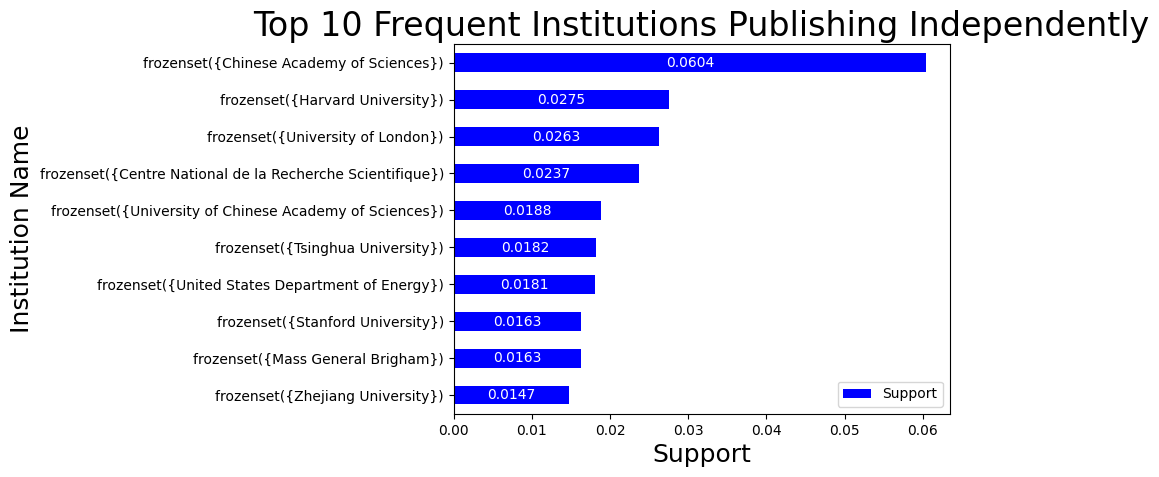

In [28]:
# Sort by support in descending order
freq_insts = freq_insts.sort_values(by='support', ascending=False)

# Plot the top ten pairs of institutions by support
# Dataframe is sorted, first 10 rows will have the highest support
top_ten_freq_insts = freq_insts.head(10).plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_freq_insts.set_title(label='Top 10 Frequent Institutions Publishing Independently', fontsize=24, color='black')
top_ten_freq_insts.set_xlabel('Support', fontsize=18, color='black')
top_ten_freq_insts.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_freq_insts.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_freq_insts.invert_yaxis()

# Annotate the bars
top_ten_freq_insts.bar_label(top_ten_freq_insts.containers[0], label_type='center', color='white')

These are the top ten institutions publishing alone that have the highest support (i.e. publish the most works). There is a lot of overlap with the top ten most cited institutions chart.

# Which Pairs of Institutions Publish Most Frequently Together?

In [29]:
print("Most frequent pairs of institutions publishing together:")
freq_inst_pairs = (
    
    # Filter to find the most frequent 2-itemsets
    frequent_itemsets[frequent_itemsets['length'] == 2]
    [['support', 'itemsets']]
)

display(freq_inst_pairs)

Most frequent pairs of institutions publishing together:


,support,itemsets
202,0.0188,"frozenset({Chinese Academy of Sciences, University of Chinese Academy of Sci..."
201,0.0139,"frozenset({University of Science and Technology of China, Chinese Academy of..."
206,0.0136,"frozenset({Office of Science, United States Department of Energy})"
211,0.0136,"frozenset({Harvard University, Mass General Brigham})"
210,0.0134,"frozenset({University of London, University College London})"
237,0.0115,"frozenset({United States Department of Health and Human Services, National I..."
212,0.0096,"frozenset({Brigham and Women's Hospital, Mass General Brigham})"
213,0.0091,"frozenset({Mass General Brigham, Massachusetts General Hospital})"
220,0.0083,"frozenset({Brigham and Women's Hospital, Harvard University})"
238,0.0073,"frozenset({United States Department of Veterans Affairs, Veterans Health Adm..."


[Text(0, 0, '0.0188'),
 Text(0, 0, '0.0139'),
 Text(0, 0, '0.0136'),
 Text(0, 0, '0.0136'),
 Text(0, 0, '0.0134'),
 Text(0, 0, '0.0115'),
 Text(0, 0, '0.0096'),
 Text(0, 0, '0.0091'),
 Text(0, 0, '0.0083'),
 Text(0, 0, '0.0073')]

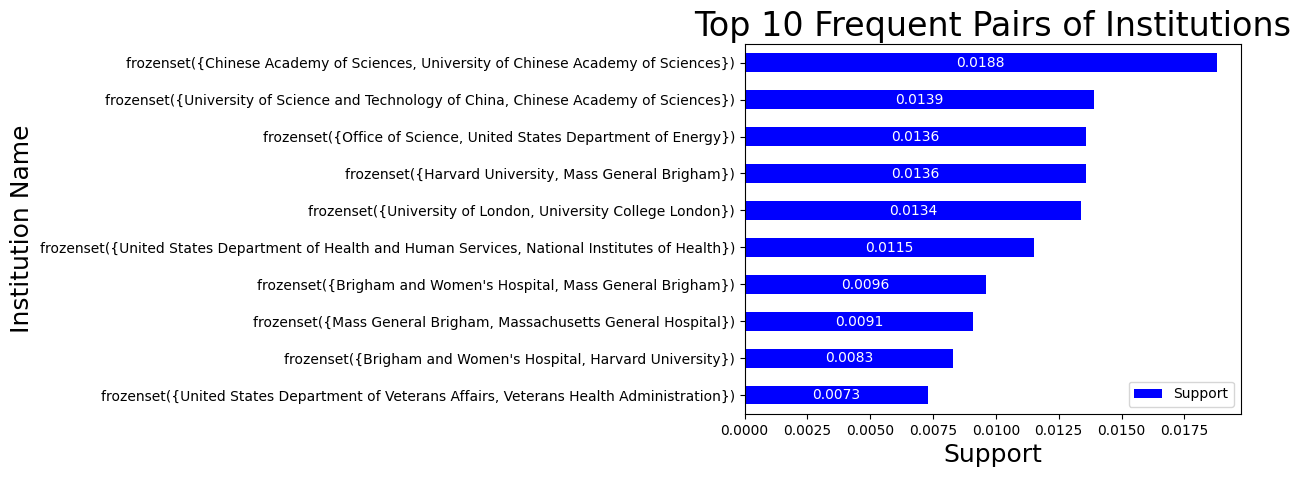

In [30]:
# Sort by support in descending order
freq_inst_pairs = freq_inst_pairs.sort_values(by='support', ascending=False)

# Plot the top ten pairs of institutions by support
# Dataframe is sorted, first 10 rows will have the highest support
top_ten_pairs = freq_inst_pairs.head(10).plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_pairs.set_title(label='Top 10 Frequent Pairs of Institutions', fontsize=24, color='black')
top_ten_pairs.set_xlabel('Support', fontsize=18, color='black')
top_ten_pairs.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_pairs.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_pairs.invert_yaxis()

# Annotate the bars
top_ten_pairs.bar_label(top_ten_pairs.containers[0], label_type='center', color='white')

These are the top ten institutions publishing together in pairs that have the highest support (i.e. publish most frequently). Interestingly, there is a less overlap with the top ten most cited institutions compared to the most frequent independent institutions, which suggests a lot of these highly cited institutions act independently. There appears to not be a lot of collaboration between the top ten most cited institutions. A lot of these institutions either collaborate within their own ecosystems or with federal institutions.

# What about Groups Larger than Two?

In [32]:
print("Most frequent groups of institutions publishing together:")
freq_inst_groups = (
    
    # Filter to find the most frequent n-itemsets where n > 2
    frequent_itemsets[frequent_itemsets['length'] > 2]
    [['support', 'itemsets']]
)

display(freq_inst_groups)

Most frequent groups of institutions publishing together:


,support,itemsets
246,0.0083,"frozenset({Brigham and Women's Hospital, Harvard University, Mass General Br..."
247,0.0071,"frozenset({Harvard University, Mass General Brigham, Massachusetts General H..."
249,0.0047,"frozenset({Commonwealth Scientific and Industrial Research Organisation, Dep..."
248,0.0041,"frozenset({Centre National de la Recherche Scientifique, Inserm, Institut de..."
245,0.0041,"frozenset({Lawrence Berkeley National Laboratory, Office of Science, United ..."
243,0.0039,"frozenset({Medical Research Council, University of Cambridge, UK Research an..."
250,0.0038,"frozenset({Ministry of Agriculture and Rural Affairs, State Council of the P..."
244,0.0036,"frozenset({Office of Science, United States Department of Energy, University..."


[Text(0, 0, '0.0083'),
 Text(0, 0, '0.0071'),
 Text(0, 0, '0.0047'),
 Text(0, 0, '0.0041'),
 Text(0, 0, '0.0041'),
 Text(0, 0, '0.0039'),
 Text(0, 0, '0.0038'),
 Text(0, 0, '0.0036')]

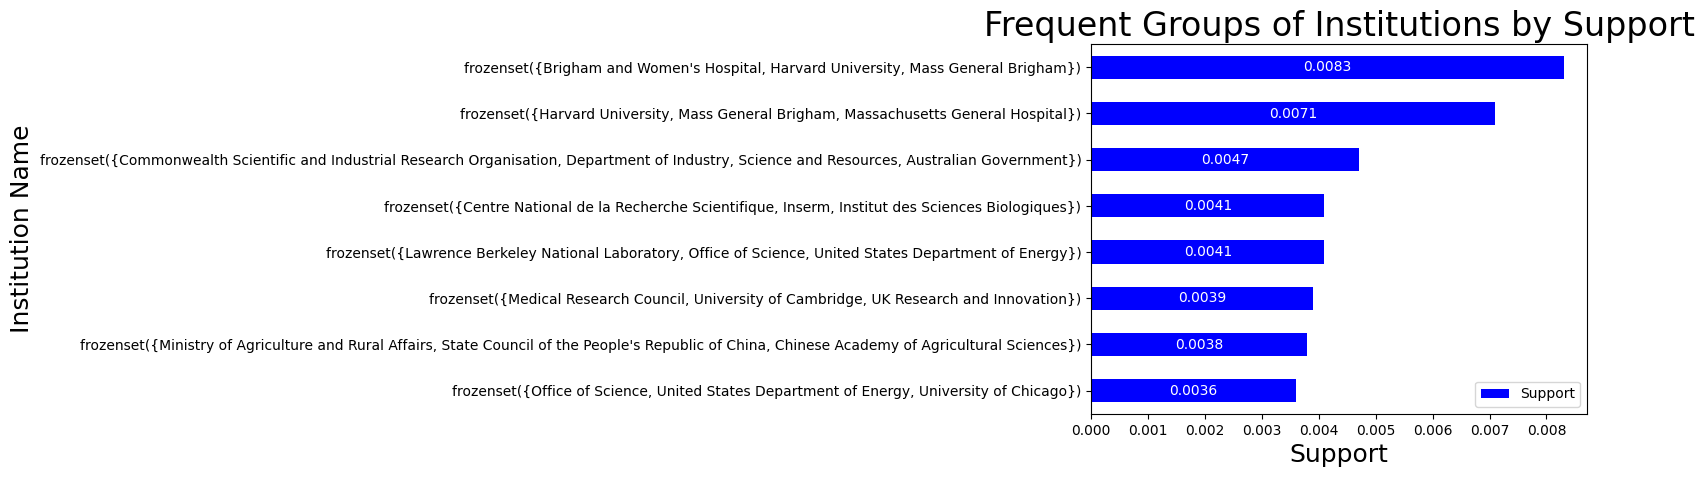

In [34]:
# Sort by support in descending order
freq_inst_groups = freq_inst_groups.sort_values(by='support', ascending=False)

# Plot the top ten groups of institutions by support
# Dataframe is sorted, only eight rows to plot
top_ten_groups = freq_inst_groups.plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_groups.set_title(label='Frequent Groups of Institutions by Support', fontsize=24, color='black')
top_ten_groups.set_xlabel('Support', fontsize=18, color='black')
top_ten_groups.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_groups.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_groups.invert_yaxis()

# Annotate the bars
top_ten_groups.bar_label(top_ten_groups.containers[0], label_type='center', color='white')

Ranks institutions publishing together in groups larger than two (there were only eight frequent itemsets larger than two) that have the highest support (i.e. publish most frequently). Similar to the most frequent pairs, there appears to not be a lot of collaboration between the top ten most cited institutions. A lot of these institutions either collaborate within their own ecosystems or with federal institutions.

## Generating Association Rules

In [35]:
# Generate rules using Kulczynski as primary means of evaluation, a symmetric measure.
rules_df = association_rules(
    frequent_itemsets,
    metric='kulczynski',
    
    # Only interested in rules with moderate symmetry between conditional probabilities
    min_threshold=0.3,
    num_itemsets=len(frequent_itemsets),
)

print(f"Generated {len(rules_df):,} association rules")
rules_df.sort_values(by='kulczynski', ascending=False).head()

Generated 138 association rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
117,frozenset({Harris Health System}),frozenset({Baylor College of Medicine}),0.0038,0.0038,0.0038,1.000000,263.157895,1.0,0.003786,inf,1.0,1.000000,1.000000,1.000000
116,frozenset({Baylor College of Medicine}),frozenset({Harris Health System}),0.0038,0.0038,0.0038,1.000000,263.157895,1.0,0.003786,inf,1.0,1.000000,1.000000,1.000000
98,frozenset({Indiana University}),frozenset({Indiana University Columbus}),0.0039,0.0039,0.0039,1.000000,256.410256,1.0,0.003885,inf,1.0,1.000000,1.000000,1.000000
99,frozenset({Indiana University Columbus}),frozenset({Indiana University}),0.0039,0.0039,0.0039,1.000000,256.410256,1.0,0.003885,inf,1.0,1.000000,1.000000,1.000000
24,frozenset({United States Department of Veterans Affairs}),frozenset({Veterans Health Administration}),0.0074,0.0073,0.0073,0.986486,135.135135,1.0,0.007246,73.4598,1.0,0.986486,0.986387,0.993243


I chose Kulczynski as my primary means of assessing rules because direction does not matter here but symmetry does. For example, if Harvard and Yale wrote a paper together it does not matter which one comes first as they are both associated with the work. The relationship needs to be symmetric to ensure that the institutions in question are actually publishing together.

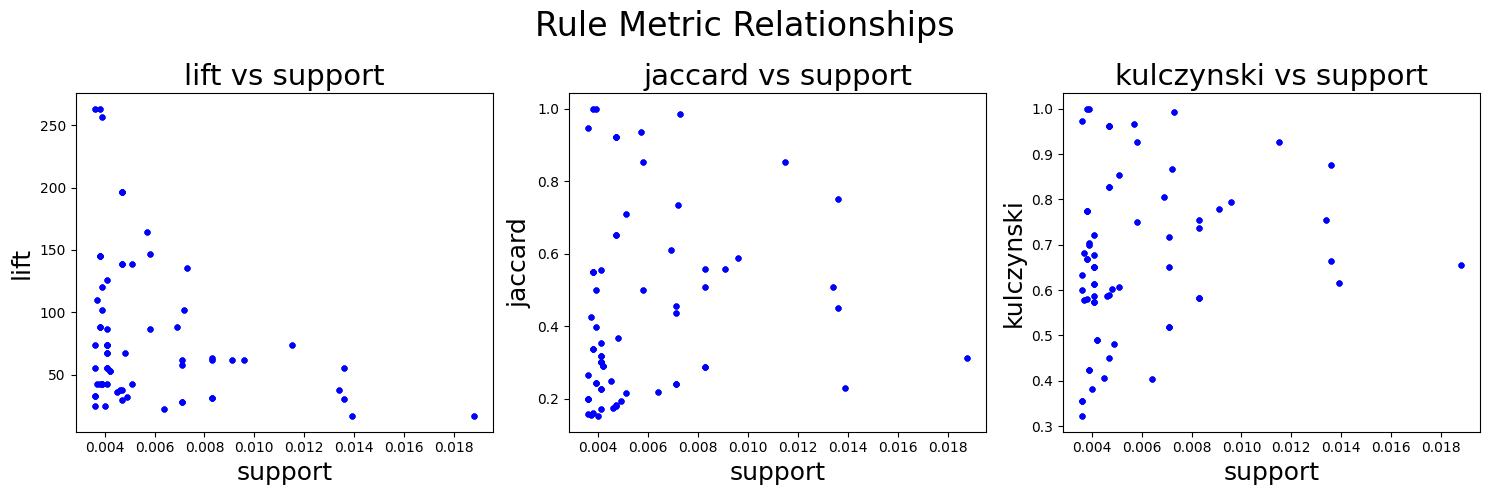

In [36]:
# Construct a 3-panel scatterplot comparing lift, jaccard, and kulczynski measures
# of the generated rule metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Construct a scatter plot for each metric, adjusted transparency, size, and color for readability
for ax, y_metric in zip(axes, ['lift', 'jaccard', 'kulczynski']):
    ax.scatter(rules_df['support'], rules_df[y_metric],
               alpha=1, s=12, color='blue')
    ax.set_xlabel('support', fontsize=18, color='black')
    ax.set_ylabel(y_metric, fontsize=18, color='black')
    ax.set_title(f'{y_metric} vs support', fontsize=21, color='black')

plt.suptitle("Rule Metric Relationships", fontsize=24, color='black')
plt.tight_layout()
plt.show()

Plots the relationships between rule metrics against support. I chose Jaccard and Kulczynski as my main means of evaluation as they are null-invariant and symmetric. As mentioned above, direction does not matter here but symmetry does. Use lift as a sanity check to help measure the strength of the correlation. Lower support values are associated with higher lift values whereas Jaccard and Kulczynski values are more evenly dispersed.

# Helper Functions for Rule Mining

In [37]:
def rules_involving(rules_df, label, side='either'):
    """
    Filter rules that involve a specific author display label.

    Parameters
    ----------
    rules_df : association rules DataFrame
    label    : str — the author display label (from author_display_map)
    side     : 'antecedent' | 'consequent' | 'either'
    """
    in_ant = rules_df['antecedents'].apply(lambda x: label in x)
    in_con = rules_df['consequents'].apply(lambda x: label in x)

    if side == 'antecedent':
        mask = in_ant
    elif side == 'consequent':
        mask = in_con
    else:
        mask = in_ant | in_con

    return rules_df[mask].sort_values('lift', ascending=False)


def rules_with_antecedent_size(rules_df, size):
    """Filter rules where the antecedent has exactly `size` items."""
    return rules_df[rules_df['antecedents'].apply(len) == size]

# Recycled from rules_with_antecedent_size to help with one of my searches
def rules_with_min_antecedent_size(rules_df, size):
    """Filter rules where the antecedent has at least `size` items."""
    return rules_df[rules_df['antecedents'].apply(len) >= size]


def rules_above_thresholds(rules_df, min_confidence=0.5, min_lift=2.0):
    """Filter rules meeting both confidence and lift thresholds."""
    return rules_df[
        (rules_df['confidence'] >= min_confidence) &
        (rules_df['lift']       >= min_lift)
    ]


def fmt_set(s):
    """Render a frozenset of author labels as a readable string."""
    return ', '.join(sorted(str(x) for x in s))

print("Helper functions defined ✅")

Helper functions defined ✅


# Filtering Rules for Institution Combinations

## 1-1 Relationships

In [38]:
# Rules with a single-instutution antecedent and single-institution consequent
inst_1_to_1_rules = (
    rules_with_antecedent_size(rules_df, 1)
    .pipe(lambda df: df[df['consequents'].apply(len) == 1])
    .sort_values(by='kulczynski', ascending=False)
)

print(f"1-institution antecedent → 1-institution consequent: {len(inst_1_to_1_rules)} rules")
inst_1_to_1_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head()

1-institution antecedent → 1-institution consequent: 90 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
117,frozenset({Harris Health System}),frozenset({Baylor College of Medicine}),0.0038,1.000000,263.157895,1.000000,1.000000
116,frozenset({Baylor College of Medicine}),frozenset({Harris Health System}),0.0038,1.000000,263.157895,1.000000,1.000000
98,frozenset({Indiana University}),frozenset({Indiana University Columbus}),0.0039,1.000000,256.410256,1.000000,1.000000
99,frozenset({Indiana University Columbus}),frozenset({Indiana University}),0.0039,1.000000,256.410256,1.000000,1.000000
24,frozenset({United States Department of Veterans Affairs}),frozenset({Veterans Health Administration}),0.0073,0.986486,135.135135,0.986486,0.993243


"If institution A wrote this work, institution B also likely helped co-author this work"

## 1-N Relationships

In [39]:
# Rules with a single-instutution antecedent and n-institution consequent
inst_1_to_n_rules = (
    rules_with_antecedent_size(rules_df, 1)
    .pipe(lambda df: df[df['consequents'].apply(len) > 1])
    .sort_values(by='kulczynski', ascending=False)
)

print(f"1-institution antecedent → n-institution consequent: {len(inst_1_to_n_rules)} rules")
inst_1_to_n_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

1-institution antecedent → n-institution consequent: 24 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
63,frozenset({Commonwealth Scientific and Industrial Research Organisation}),"frozenset({Department of Industry, Science and Resources, Australian Governm...",0.0047,1.000000,196.078431,0.921569,0.960784
64,"frozenset({Department of Industry, Science and Resources})","frozenset({Commonwealth Scientific and Industrial Research Organisation, Aus...",0.0047,0.921569,196.078431,0.921569,0.960784
65,frozenset({Australian Government}),"frozenset({Commonwealth Scientific and Industrial Research Organisation, Dep...",0.0047,0.652778,138.888889,0.652778,0.826389
111,frozenset({Ministry of Agriculture and Rural Affairs}),"frozenset({State Council of the People's Republic of China, Chinese Academy ...",0.0038,0.550725,144.927536,0.550725,0.775362
113,frozenset({Chinese Academy of Agricultural Sciences}),"frozenset({Ministry of Agriculture and Rural Affairs, State Council of the P...",0.0038,1.000000,144.927536,0.550725,0.775362
23,frozenset({Mass General Brigham}),"frozenset({Brigham and Women's Hospital, Harvard University})",0.0083,0.509202,61.349693,0.509202,0.754601
21,frozenset({Brigham and Women's Hospital}),"frozenset({Harvard University, Mass General Brigham})",0.0083,0.864583,63.572304,0.557047,0.737439
85,frozenset({Institut des Sciences Biologiques}),"frozenset({Centre National de la Recherche Scientifique, Inserm})",0.0041,0.803922,125.612745,0.554054,0.722273
34,frozenset({Mass General Brigham}),"frozenset({Harvard University, Massachusetts General Hospital})",0.0071,0.435583,61.349693,0.435583,0.717791
103,frozenset({Medical Research Council}),"frozenset({University of Cambridge, UK Research and Innovation})",0.0039,0.541667,120.370370,0.500000,0.704167


"If institution A wrote this work, institutions B and C also likely helped co-author this work"

## N-1 Relationships

In [40]:
# Rules with an n-instutution antecedent and single-institution consequent
inst_n_to_1_rules = (

    # See helper functions
    rules_with_min_antecedent_size(rules_df, 2)
    .pipe(lambda df: df[df['consequents'].apply(len) == 1])
    .sort_values(by='kulczynski', ascending=False)
)

print(f"n-institution antecedent → 1-institution consequent: {len(inst_n_to_1_rules)} rules")
inst_n_to_1_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

n-institution antecedent → 1-institution consequent: 24 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
61,"frozenset({Commonwealth Scientific and Industrial Research Organisation, Aus...","frozenset({Department of Industry, Science and Resources})",0.0047,1.000000,196.078431,0.921569,0.960784
62,"frozenset({Department of Industry, Science and Resources, Australian Governm...",frozenset({Commonwealth Scientific and Industrial Research Organisation}),0.0047,0.921569,196.078431,0.921569,0.960784
60,"frozenset({Commonwealth Scientific and Industrial Research Organisation, Dep...",frozenset({Australian Government}),0.0047,1.000000,138.888889,0.652778,0.826389
108,"frozenset({Ministry of Agriculture and Rural Affairs, State Council of the P...",frozenset({Chinese Academy of Agricultural Sciences}),0.0038,0.550725,144.927536,0.550725,0.775362
110,"frozenset({State Council of the People's Republic of China, Chinese Academy ...",frozenset({Ministry of Agriculture and Rural Affairs}),0.0038,1.000000,144.927536,0.550725,0.775362
18,"frozenset({Brigham and Women's Hospital, Harvard University})",frozenset({Mass General Brigham}),0.0083,1.000000,61.349693,0.509202,0.754601
20,"frozenset({Harvard University, Mass General Brigham})",frozenset({Brigham and Women's Hospital}),0.0083,0.610294,63.572304,0.557047,0.737439
80,"frozenset({Centre National de la Recherche Scientifique, Inserm})",frozenset({Institut des Sciences Biologiques}),0.0041,0.640625,125.612745,0.554054,0.722273
31,"frozenset({Harvard University, Massachusetts General Hospital})",frozenset({Mass General Brigham}),0.0071,1.000000,61.349693,0.435583,0.717791
102,"frozenset({University of Cambridge, UK Research and Innovation})",frozenset({Medical Research Council}),0.0039,0.866667,120.370370,0.500000,0.704167


"If institutions A and B wrote this work together, institution C also likely helped co-author this work"